# Exploratory Data Analysis (EDA)
## Insurance Dataset using DuckDB

This notebook performs exploratory data analysis on the insurance dataset located in the bronze layer.

Goals:
- Demonstrate EDA workflow
- Use DuckDB to query CSV files
- Generate visual insights
- Prepare for Bronze → Silver → Gold pipeline


## 1. Setup Environment

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 2. Connect to DuckDB

In [ ]:
con = duckdb.connect('insurance_eda.duckdb')

In [3]:
print("con=", con)

con= <_duckdb.DuckDBPyConnection object at 0x11b6f4630>


## 3. Load Bronze Data (All CSV Files)

In [4]:
df = con.execute("""
SELECT *
FROM read_csv_auto('insurance/data/bronze/insurance.*.csv')
""").df()
df.head()

,age,gender,bmi,children,smoker,region,charges
0,22,female,23.20,1,False,northwest,5605.93
1,54,male,30.60,0,False,northeast,7118.87
2,48,male,31.31,0,True,southwest,40381.51
3,38,female,27.49,0,True,southwest,21178.05
4,38,male,33.10,0,False,northwest,12829.41


## 4. Basic Dataset Information

In [5]:
df.shape

(5200, 7)

In [6]:
df.columns

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [7]:
df.dtypes

age           int64
gender       object
bmi         float64
children      int64
smoker         bool
region       object
charges     float64
dtype: object

## 5. Summary Statistics

In [8]:
df.describe()

,age,bmi,children,charges
count,5200.000000,5200.000000,5200.000000,5200.000000
mean,41.075192,30.138513,1.095192,16851.666160
std,13.634624,6.093932,1.274868,11742.293309
min,18.000000,15.500000,0.000000,200.000000
25%,29.000000,25.977500,0.000000,8455.912500
50%,41.000000,30.120000,1.000000,13695.950000
75%,53.000000,34.212500,2.000000,21321.715000
max,64.000000,52.000000,5.000000,61974.250000


## 6. Missing Values

In [9]:
df.isnull().sum()

age         0
gender      0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## 7. Age Distribution

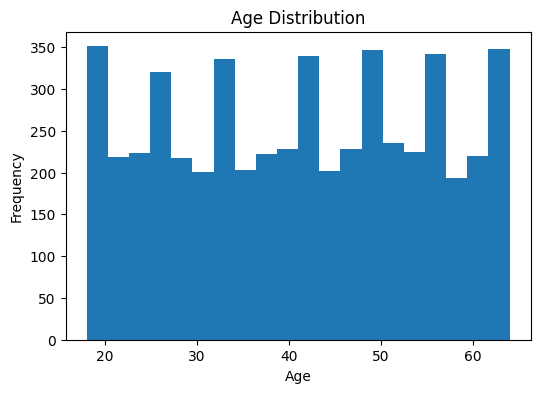

In [10]:
plt.figure(figsize=(6,4))
plt.hist(df['age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

## 8. BMI Distribution

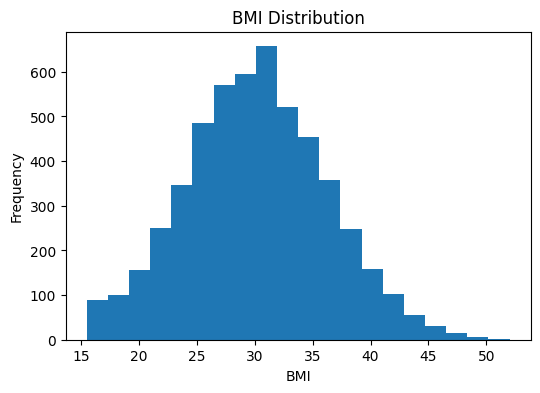

In [11]:
plt.figure(figsize=(6,4))
plt.hist(df['bmi'], bins=20)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

## 9. Charges Distribution

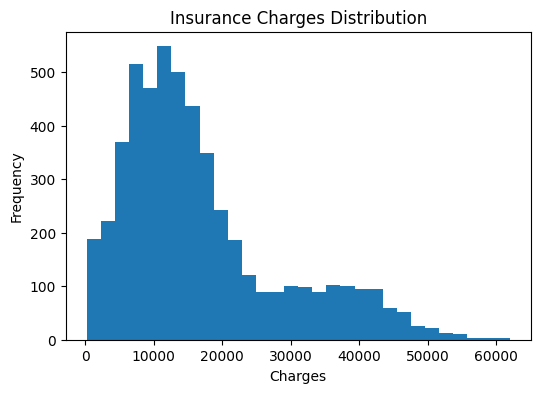

In [12]:
plt.figure(figsize=(6,4))
plt.hist(df['charges'], bins=30)
plt.title('Insurance Charges Distribution')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

## 10. Gender Distribution

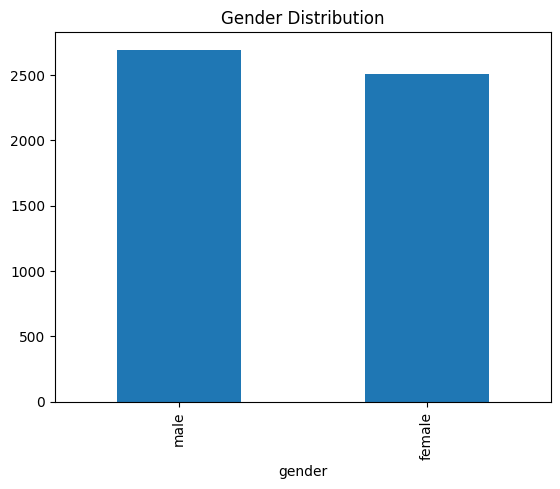

In [13]:
df['gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.show()

## 11. Region Distribution

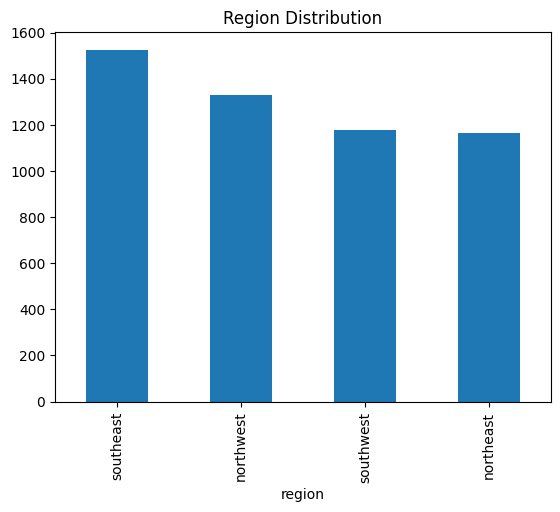

In [14]:
df['region'].value_counts().plot(kind='bar')
plt.title('Region Distribution')
plt.show()

## 12. Smokers vs Charges

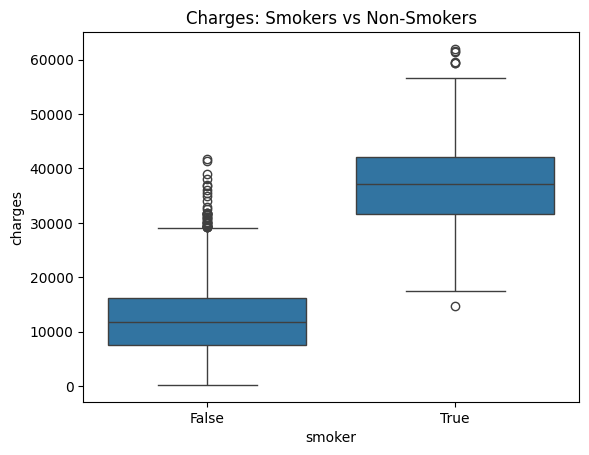

In [15]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges: Smokers vs Non-Smokers')
plt.show()

## 13. BMI vs Charges

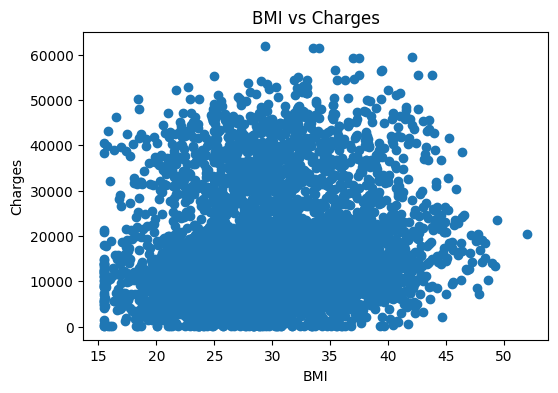

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(df['bmi'], df['charges'])
plt.title('BMI vs Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

## 14. Average Charges by Region

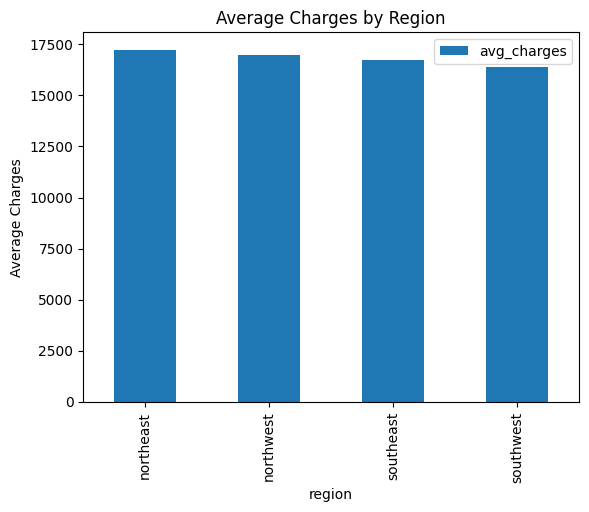

In [17]:
region_charges = con.execute("""
SELECT region, AVG(charges) avg_charges
FROM df
GROUP BY region
ORDER BY avg_charges DESC
""").df()

region_charges.plot(kind='bar', x='region', y='avg_charges')
plt.title('Average Charges by Region')
plt.ylabel('Average Charges')
plt.show()

## 15. Correlation Matrix

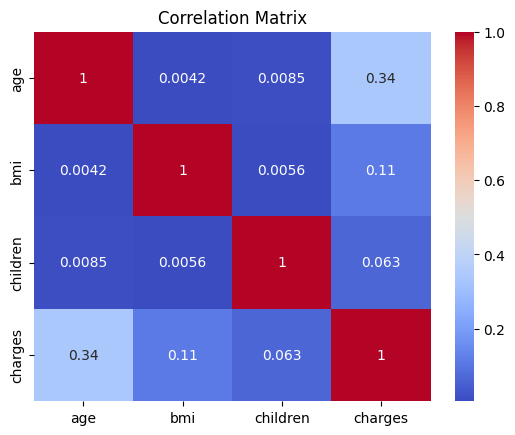

In [18]:
corr = df[['age','bmi','children','charges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Key Insights
- Smokers tend to have significantly higher insurance charges.
- Age appears positively correlated with charges.
- BMI shows moderate correlation with charges.
- Regional differences are relatively small.

Next step: move from **Bronze → Silver → Gold** in a Medallion Architecture pipeline.